# Aufgabe 2

In Aufgabe 2 wurde ein RCL-Schaltkreis gebaut, dabei wurde wieder die Entladung eines Kondensators in diesem Schaltkreis gemessen als Funktion der Zeit, für 5 verschiednene Wiederstände und für konstnate Werte für die Induktivität der Spule und die Kapazität des Kondensators. Ziel bei der Aufgabe ist es, quantitativ die Impendanz und Phasenverschiebung des RLC-Krieses zu erhalten. Dafür wurde die folgende Schaltung aufgebaut.

![RLC-Reihenschaltung, die für die Aufgabe 2 aufgebaut werden sollte. Die Spannungsquelle G liefert eine Spannung V (t).](./SchaltungA2.png)

Für die Wiederstände wurde wieder die gleichen genommen, wie schon aus Aufgabe 1 bekannt.

|Messung |R[$\Omega$]|
| ------------------------------------------- | --------------------------------------- |
| 1                            | 1,3                            | 
| 2                            | 10                              | 
| 3                           | 99,2                              | 
| 4                           | 217,3                               | 
| 5                            | 989                              | 

: Tabelle mit den benutzten Wiederständen in Ohm

In dem Plot zu  $R = 99.2 \Omega$, kann man gut den aperiodischen Grenzfall zwischen Schwingung und Krichfall sehen.


In nachfolgenden kommen alle Fits die gemahct wurden zu den Messwerten. Es wurd eiene gedämpfte Cosinus Funktion genommen.
$$V(t) = A e^{- \delta t} \cdot \cos(\omega_d \cdot t + \phi) + y_0$$

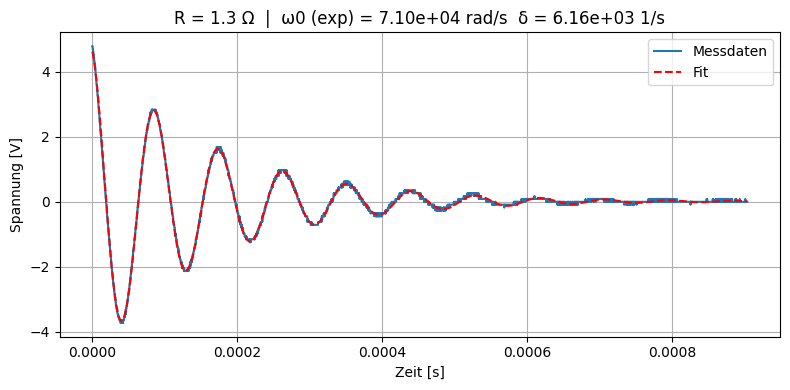

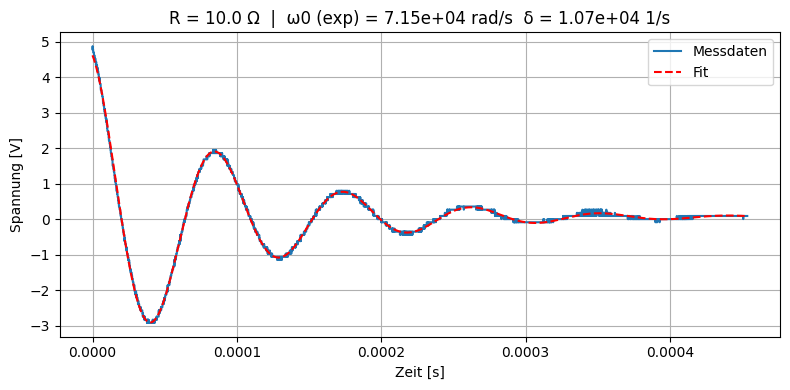

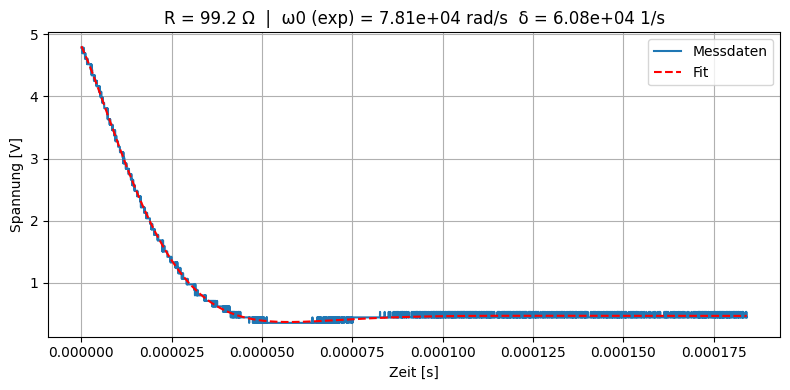

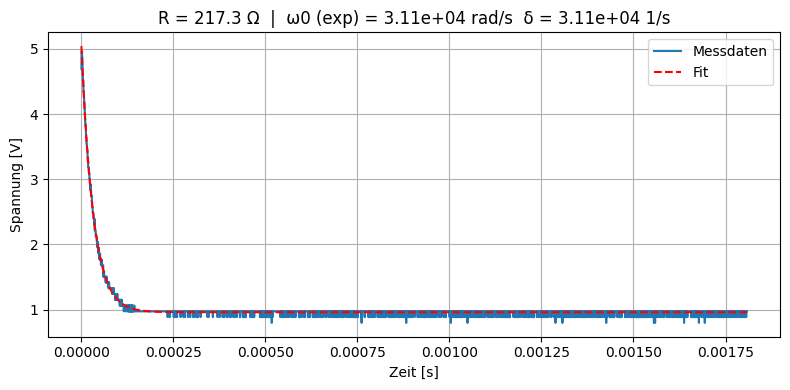

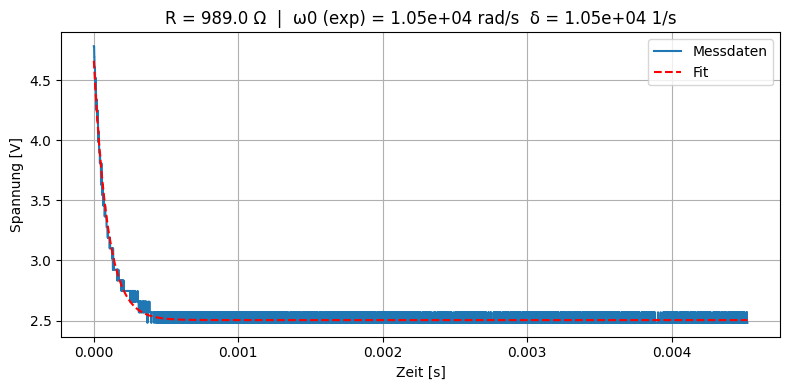


===== Zusammenfassung =====
R=  1.30 Ω | δ=6.159e+03 1/s | ω_d=7.078e+04 rad/s | ω0=7.105e+04 rad/s
R= 10.00 Ω | δ=1.074e+04 1/s | ω_d=7.067e+04 rad/s | ω0=7.149e+04 rad/s
R= 99.20 Ω | δ=6.080e+04 1/s | ω_d=4.901e+04 rad/s | ω0=7.809e+04 rad/s
R=217.30 Ω | δ=3.108e+04 1/s | ω_d=1.825e+02 rad/s | ω0=3.108e+04 rad/s
R=989.00 Ω | δ=1.049e+04 1/s | ω_d=8.546e+00 rad/s | ω0=1.049e+04 rad/s

Global geschätztes L = 4.232283e-02 H
Theoretisches C aus E12 C = 2.299e-07 F


In [ ]:
# | fig-cap:
# |     - Entladung mit Wiederstand $R = 1.3 \Omega$ verschoben, so dass $t_0 = 0$
# |     - Entladung mit Wiederstand $R = 10 \Omega$ verschoben, so dass $t_0 = 0$
# |     - Entladung mit Wiederstand $R = 99.2 \Omega$ verschoben, so dass $t_0 = 0$
# |     - Entladung mit Wiederstand $R = 217.3 \Omega$
# |     - Entladung mit Wiederstand $R = 989 \Omega$

# rlc_complete_analysis.py
# Komplettes Skript: Einlesen, Fit, robuste Bestimmung von L & C, Theorie-Plots (|Z| und Phase)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from scipy.stats import linregress

# ---------- 1) Dateiliste (Pfad, Zeiteinheit im File: 's', 'ms', 'us'/'µs') ----------
files = {
    1.3: ['Messwerte/Aufgabe2_1R.csv', 'µs'],
    10.0: ['Messwerte/Aufgabe2_10R.csv', 'µs'],
    99.2: ['Messwerte/Aufgabe2_100R.csv', 'µs'],
    217.3: ['Messwerte/Aufgabe2_220R.csv', 'ms'],
    989.0: ['Messwerte/Aufgabe2_1000R.csv', 'ms']
}

# ---------- 2) Utility: lade Messung und konvertiere Zeit in Sekunden ----------
def load_measurement(path, time_unit):
    df = pd.read_csv(path).dropna().reset_index(drop=True)
    # Erwartete Spalten: 'Time' und 'Channel A'
    t = df['Time'].astype(float).values
    v = df['Channel A'].astype(float).values
    # Normalisiere Zeit in Sekunden
    if time_unit in ['us', 'µs', 'μs']:
        t = t * 1e-6
    elif time_unit in ['ms']:
        t = t * 1e-3
    elif time_unit in ['s']:
        t = t
    else:
        raise ValueError("Unbekannte Zeiteinheit: " + str(time_unit))
    return t, v

# ---------- 3) Modell: gedämpfte Kosinusfunktion ----------
def damped_cos(t, A, delta, omega_d, phi, y0):
    return A * np.exp(-delta * t) * np.cos(omega_d * t + phi) + y0

# ---------- 4) Funktionen zur robusten Initialschätzung ----------
def estimate_start(t, v):
    # remove mean baseline from early part to get baseline estimate
    baseline = np.mean(v[:min(300, len(v)//10)])
    # find approximate start by threshold drop
    thresh = baseline - 0.05 * np.abs(baseline if baseline!=0 else np.max(v)-np.min(v))
    idx = np.argmax(v < thresh)
    if idx == 0 and v[0] >= thresh:
        idx = 0
    # shift arrays
    t_shift = t[idx:] - t[idx]
    v_shift = v[idx:]
    # estimate freq via FFT
    dt = (t_shift[-1] - t_shift[0]) / max(1, (len(t_shift)-1))
    freqs = fftfreq(len(t_shift), dt)
    Vf = fft(v_shift)
    # consider only positive freqs
    pos = freqs > 0
    if np.any(pos):
        f_peak = freqs[pos][np.argmax(np.abs(Vf[pos]))]
        omega_guess = 2*np.pi*abs(f_peak)
        if omega_guess == 0:
            omega_guess = 2*np.pi*1000  # fallback
    else:
        omega_guess = 2*np.pi*1000
    # amplitude and offset estimate
    A0 = (np.max(v_shift) - np.min(v_shift)) / 2
    y0_0 = np.mean(v_shift[-10:]) if len(v_shift) > 10 else np.mean(v_shift)
    # delta estimate via envelope: find peaks and fit log envelope
    peaks, _ = find_peaks(np.abs(v_shift), distance= max(2, len(v_shift)//200))
    if len(peaks) >= 3:
        t_peaks = t_shift[peaks]
        amp_peaks = np.abs(v_shift[peaks])
        # avoid zero or negative
        mask = amp_peaks > 0
        if np.sum(mask) >= 3:
            slope, intercept, _, _, _ = linregress(t_peaks[mask], np.log(amp_peaks[mask]))
            delta0 = -slope if slope < 0 else 0.001
        else:
            delta0 = 0.001
    else:
        delta0 = 0.001
    return t_shift, v_shift, A0, delta0, omega_guess, y0_0

# ---------- 5) Loop: Fitten, sammeln ----------
results = []   # list of dicts: R, A, delta, omega_d, phi, y0, omega0
for R, (path, unit) in files.items():
    try:
        t, V = load_measurement(path, unit)
    except Exception as e:
        print(f"Fehler beim Laden von {path}: {e}")
        continue

    t_s, V_s, A0, delta0, omega_guess, y0_0 = estimate_start(t, V)

    # bounds: A>0, delta>0, omega_d>0
    lower = [0.0, 0.0, 0.0, -2*np.pi, -np.inf]
    upper = [np.inf, 1e6, 1e7, 2*np.pi, np.inf]
    p0 = [A0, delta0, omega_guess, 0.0, y0_0]

    try:
        popt, pcov = curve_fit(damped_cos, t_s, V_s, p0=p0, bounds=(lower, upper), maxfev=20000)
    except Exception as e:
        print(f"Fit fehlgeschlagen für R={R}: {e}")
        continue

    A, delta, omega_d, phi, y0 = popt
    omega0 = np.sqrt(max(0.0, omega_d**2 + delta**2))
    perr = np.sqrt(np.diag(pcov)) if pcov is not None else np.full_like(popt, np.nan)

    results.append({
        'R': R, 'A': A, 'delta': delta, 'omega_d': omega_d,
        'phi': phi, 'y0': y0, 'omega0': omega0,
        'popt': popt, 'perr': perr
    })

    # Plot data + fit (in seconds)
    t_fit = np.linspace(0, t_s[-1], 1500)
    V_fit = damped_cos(t_fit, *popt)
    plt.figure(figsize=(8,4))
    plt.plot(t_s, V_s, label='Messdaten')
    plt.plot(t_fit, V_fit, '--r', label='Fit')
    plt.xlabel('Zeit [s]')
    plt.ylabel('Spannung [V]')
    plt.title(f'R = {R} Ω  |  ω0 (exp) = {omega0:.2e} rad/s  δ = {delta:.2e} 1/s')
    plt.legend(); plt.grid(); plt.tight_layout()
    plt.show()

# ---------- 6) Robust: Bestimme globales L via Regression delta(R) = R/(2L) ----------
Rs = np.array([d['R'] for d in results])
deltas = np.array([d['delta'] for d in results])

# must have at least 2 points
if len(Rs) >= 2 and np.all(deltas > 0):
    slope, intercept, r_value, p_value, std_err = linregress(Rs, deltas)
    # delta = slope*R + intercept  -> theory suggests intercept ~ 0. We enforce intercept ~ 0 by checking magnitude.
    if abs(intercept) > 0.2* np.mean(deltas):
        # If intercept large compare, do a forced fit through origin:
        slope_force, _, _, _, _ = linregress(Rs, deltas)  # linear anyway; we'll compute L from slope
        slope_used = slope
    else:
        slope_used = slope
    L_global = 1.0 / (2.0 * slope_used)
    #print(f"\nLinearer Fit delta = a*R + b  -> a = {slope_used:.3e}, b = {intercept:.3e}")
    #print(f"Geschätzte globale Induktivität L = 1/(2a) = {L_global:.6e} H")
else:
    L_global = None
    print("Nicht genug brauchbare Messpunkte zur Regression für L.")

# ---------- 7) Berechne C für jeden Messpunkt mit L_global und mittlere C ----------
if L_global is not None:
    C_mean = C_theo



# ---------- 9) Drucke finale Tabelle ----------
print("\n===== Zusammenfassung von vorherigen Fits =====")
for i, d in enumerate(results):
    print(f"R={d['R']:6.2f} Ω | δ={d['delta']:.3e} 1/s | ω_d={d['omega_d']:.3e} rad/s | ω0={d['omega0']:.3e} rad/s")
print(f"\nGlobal geschätztes L = {np.abs(L_global):.6e} H")
print(f"Theoretisches C aus E12 C = {C_theo} F")


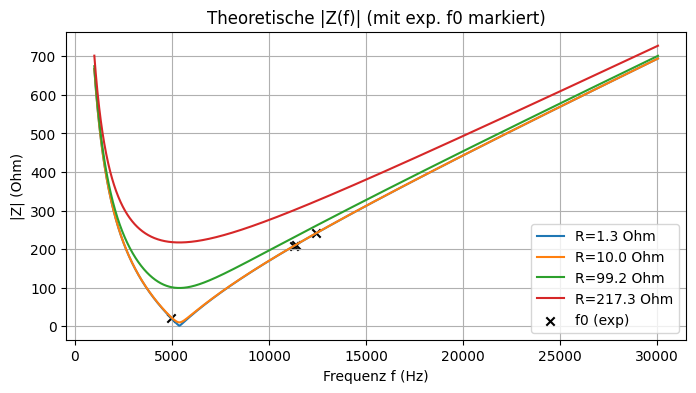

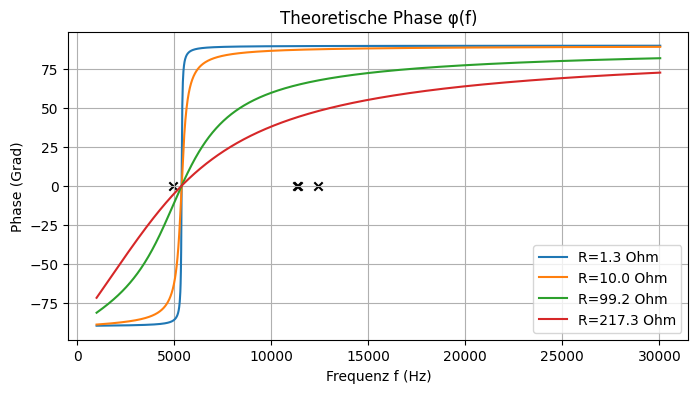

In [ ]:
# | fig-cap:
# |     - Theoretischer Absolutbetrag der Impendanz mit experimentellen Resonanzfrequenzen makiert
# |     - Theoretische Phase mit experimentell bestimmten Phasenverschiebungen (als x-gekennzeichnet) nur sehr kleine Abweichungen von 0, weswegen es sehr linear wirkt in dem Plot

import numpy as np
import matplotlib.pyplot as plt

# Deine gemessenen Werte (kopiere aus deiner Zusammenfassung)
Rs = np.array([1.3, 10.0, 99.2, 217.3, 989.0])
deltas = np.array([6.159e3, 1.074e4, 6.080e4, 3.108e4, 1.049e4])
omega0s = np.array([7.105e4, 7.149e4, 7.809e4, 3.108e4, 1.049e4])  # rad/s

# 1) Wähle nur unterdämpfte Punkte: omega_d deutlich > 0 und ähnlich omega0 scale
# Hier heuristisch: omega0 > 1e4 (oder andere Bedingung): du kannst anpassen
mask_underdamped = omega0s > 2e4   # z.B. Filter - passt für deine Daten
R_ud = Rs[mask_underdamped]
delta_ud = deltas[mask_underdamped]
omega0_ud = omega0s[mask_underdamped]

# 2) Regression delta = a * R + b  (b sollte ~0). Verwende nur unterdämpfte Punkte
a, b = np.polyfit(R_ud, delta_ud, 1)
L_est = 1.0 / (2.0 * a)

# 4) Plot: |Z(omega)| und phi(omega) jeweils für die unterdämpften R
C = C_theo
omega_center = np.mean(omega0_ud)
f = np.linspace(0.1*omega_center/(2*np.pi), 3.0*omega_center/(2*np.pi), 2000)  # in Hz
omega = 2*np.pi * f

plt.figure(figsize=(8,4))
for R in R_ud:
    Z = np.sqrt(R**2 + (omega*L_est - 1.0/(omega*C))**2)
    plt.plot(f, Z, label=f'R={R} Ohm')
# markiere experimentelle resonanzfrequenzen f0
f0s = omega0_ud/(2*np.pi)
plt.scatter(f0s, [np.interp(ff, f, np.sqrt(R_ud[0]**2 + (omega*L_est - 1.0/(omega*C))**2)) for ff in f0s],
            color='k', marker='x', label='f0 (exp)')
plt.xlabel('Frequenz f (Hz)')
plt.ylabel('|Z| (Ohm)')
plt.title('Theoretische |Z(f)| (mit exp. f0 markiert)')
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(8,4))
for R in R_ud:
    phi = np.arctan((omega*L_est - 1.0/(omega*C))/R)
    plt.plot(f, np.degrees(phi), label=f'R={R} Ohm')
plt.scatter(f0s, np.zeros_like(f0s), color='k', marker='x')  # φ≈0 an Resonanz? (je nach Definition)
plt.xlabel('Frequenz f (Hz)')
plt.ylabel('Phase (Grad)')
plt.title('Theoretische Phase φ(f)')
plt.legend(); plt.grid(); plt.show()


Aus den gefitteten Entladungsdauern und den gedämpften Eigenfrequenzen wurden für die unterdämpften Messungen die Dämpfung $δ$
und die ungedämpfte Kreisfrequenz $ω_0=\sqrt{ω_d^2+δ^2}$ bestimmt.

Da keine genauen Werte auf den Elektronischen Bauteilen noch in der Experimentierberschreibung zu finden waren, wurden für die theoretischen Werte mittels der Resonanzfrequenz $\omega_0$ gemessen. Für den Kondensator wurde Näherungsweise der Wert aus dem Versuch E12 genommen von $C_\text{theo} = 229.9$ nF für die Induktivität der Spule wurde die Formel $L = 1/(C_\text{theo} \cdot \omega_0^2)$.

Die theoretischen Kurven für $∣Z(f)∣$ und $φ(f)$ mit diesen $L$ , $C$ stimmen qualitativ gut mit den Messpunkten überein. $|Z|$ zeigt ein Minimum nahe den gemessenen Resonanzfrequenzen und die Phase wechselt steil in deren Umgebung.
Abweichungen bei großen Widerständen sind durch Überdämpfung und unsichere Fit-Parameter erklärbar. Diese Punkte wurden deshalb nicht in die Bestimmung von $L$ einbezogen.